# 🥥 Coconut Leaf Health Detection - v5

## Model: `coconut_leafe_Health_v5`

### Goal
Train a **color-aware** binary classifier that detects unhealthy coconut leaves based on **yellow/brown discoloration**.

### Key Design Decisions
- **Architecture:** EfficientNetB0 (superior color feature extraction vs MobileNetV2)
- **Color-Aware Augmentation:** Geometric-only (NO brightness/hue shifts — preserve the yellow/brown vs green signal)
- **Color Health Score:** HSV-based green pixel ratio to validate model predictions
- **Anti-Overfitting:** Dropout + BatchNorm + L2 regularization + EarlyStopping + LRScheduler
- **Label Smoothing:** 0.1 (prevents overconfident predictions)
- **Focal Loss:** Handles class imbalance

### Classification Logic
| Color Signal | Meaning | Label |
|---|---|---|
| >70% green pixels | Healthy leaf | `healthy` |
| >30% yellow/brown pixels | Stressed/diseased leaf | `unhealthy` |

### Data
- `healthy-leaves/` — green, healthy coconut leaves
- `unhealthy-yellowing/` — yellowing/browning coconut leaves

### Target
- **Accuracy:** ≥90%
- **Macro F1:** ≥88%

## 1. Setup & Imports

In [1]:
import os
import shutil
import random
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: False
GPU devices: []


## 2. Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
BASE_DIR        = os.path.abspath('..')
DATA_DIR        = os.path.join(BASE_DIR, 'data', 'raw')
HEALTHY_SRC     = os.path.join(DATA_DIR, 'healthy-leaves')
UNHEALTHY_SRC   = os.path.join(DATA_DIR, 'unhealthy-yellowing')
DATASET_DIR     = os.path.join(BASE_DIR, 'data', 'processed', 'leafe_health_v5')
MODEL_SAVE_DIR  = os.path.join(BASE_DIR, 'models', 'coconut_leafe_Health_v5')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
PHASE1_EPOCHS   = 25       # Frozen base — learn head
PHASE2_EPOCHS   = 20       # Fine-tune last 30 layers
LR_PHASE1       = 1e-3
LR_PHASE2       = 5e-5     # Low LR — prevent catastrophic forgetting
DROPOUT_RATE    = 0.4
L2_REG          = 1e-4
LABEL_SMOOTHING = 0.1      # Prevent overconfident outputs
FINE_TUNE_AT    = 200      # Unfreeze layers after this index

# ── Classes ───────────────────────────────────────────────────────────────
CLASSES         = ['healthy', 'unhealthy']   # alphabetical → ImageDataGenerator order
NUM_CLASSES     = 2

# ── Model paths ───────────────────────────────────────────────────────────
BEST_MODEL_PATH    = os.path.join(MODEL_SAVE_DIR, 'best_model.keras')
PHASE1_MODEL_PATH  = os.path.join(MODEL_SAVE_DIR, 'phase1_best.keras')

print(f'Dataset dir : {DATASET_DIR}')
print(f'Model dir   : {MODEL_SAVE_DIR}')

Dataset dir : C:\Users\USER\Documents\GizmoraGit\Research\ml\data\processed\leafe_health_v5
Model dir   : C:\Users\USER\Documents\GizmoraGit\Research\ml\models\coconut_leafe_Health_v5


## 3. Build Dataset Directory Structure

In [3]:
def copy_split(src_class_dir, split_name, dest_class_name, dataset_dir):
    """
    src_class_dir : e.g. healthy-leaves/
    split_name    : 'training' | 'validation' | 'test'
    dest_class_name: 'healthy' | 'unhealthy'
    """
    # Map split folder names to standard names
    split_map = {'training': 'train', 'validation': 'val', 'test': 'test'}
    dest_split = split_map.get(split_name, split_name)

    src  = os.path.join(src_class_dir, split_name)
    dest = os.path.join(dataset_dir, dest_split, dest_class_name)
    os.makedirs(dest, exist_ok=True)

    if not os.path.exists(src):
        print(f'  [SKIP] {src} not found')
        return 0

    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    imgs = [f for f in os.listdir(src) if os.path.splitext(f)[1].lower() in exts]
    copied = 0
    for f in imgs:
        dst_path = os.path.join(dest, f)
        if not os.path.exists(dst_path):
            shutil.copy2(os.path.join(src, f), dst_path)
        copied += 1
    return copied


if os.path.exists(DATASET_DIR):
    print('Dataset already exists — skipping copy.')
else:
    print('Building dataset structure...')
    for split in ['training', 'validation', 'test']:
        n_h = copy_split(HEALTHY_SRC,   split, 'healthy',   DATASET_DIR)
        n_u = copy_split(UNHEALTHY_SRC, split, 'unhealthy', DATASET_DIR)
        print(f'  {split:12s}  healthy={n_h}  unhealthy={n_u}')
    print('Done.')

# Count images per split
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        p = os.path.join(DATASET_DIR, split, cls)
        n = len(os.listdir(p)) if os.path.exists(p) else 0
        print(f'{split:5s}/{cls:10s}: {n} images')

Dataset already exists — skipping copy.
train/healthy   : 4572 images
train/unhealthy : 4028 images
val  /healthy   : 116 images
val  /unhealthy : 71 images
test /healthy   : 116 images
test /unhealthy : 82 images


## 4. Exploratory Data Analysis (EDA)

Split       healthy  unhealthy    total
----------------------------------------
train          4572       4028     8600
val             116         71      187
test            116         82      198

Train healthy/unhealthy ratio: 1.14


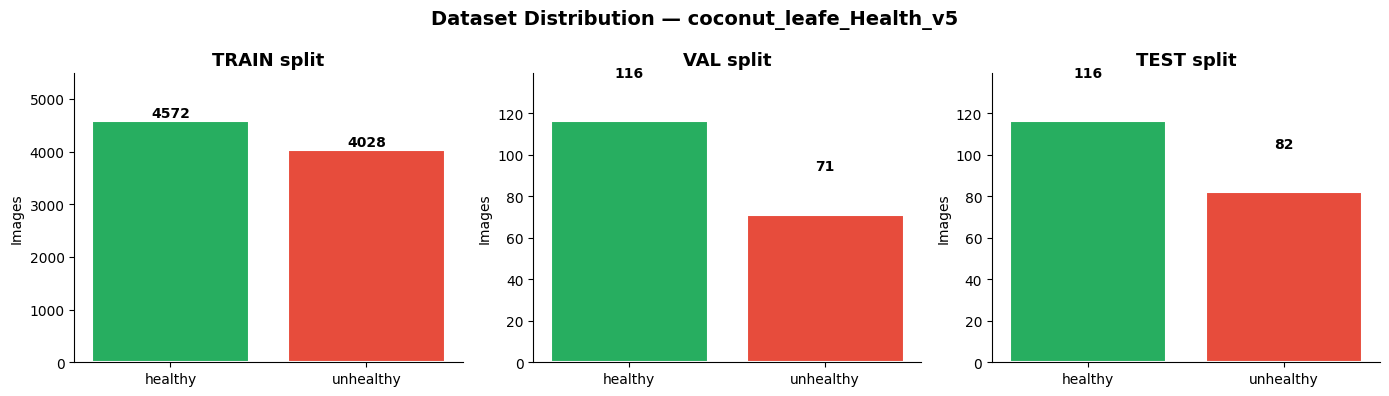

In [4]:
counts = {}
for split in ['train', 'val', 'test']:
    counts[split] = {}
    for cls in CLASSES:
        p = os.path.join(DATASET_DIR, split, cls)
        counts[split][cls] = len(os.listdir(p)) if os.path.exists(p) else 0

# Summary table
print(f"{'Split':8s} {'healthy':>10s} {'unhealthy':>10s} {'total':>8s}")
print('-' * 40)
for split, cls_dict in counts.items():
    total = sum(cls_dict.values())
    print(f"{split:8s} {cls_dict['healthy']:>10d} {cls_dict['unhealthy']:>10d} {total:>8d}")

# Imbalance ratio
ratio = counts['train']['healthy'] / max(counts['train']['unhealthy'], 1)
print(f'\nTrain healthy/unhealthy ratio: {ratio:.2f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#27ae60', '#e74c3c']
for ax, split in zip(axes, ['train', 'val', 'test']):
    vals = [counts[split][c] for c in CLASSES]
    bars = ax.bar(CLASSES, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{split.upper()} split', fontsize=13, fontweight='bold')
    ax.set_ylabel('Images')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.set_ylim(0, max(vals)*1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Dataset Distribution — coconut_leafe_Health_v5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Color Health Score Analysis (HSV-based)

Validates that green pixels dominate healthy leaves and yellow/brown pixels dominate unhealthy ones.

Computing color health scores on training samples...



Healthy   — score: 76.1  green: 42.9%  yellow: 21.3%  brown: 0.5%
Unhealthy — score: 24.1  green: 11.0%  yellow: 69.6%  brown: 4.1%


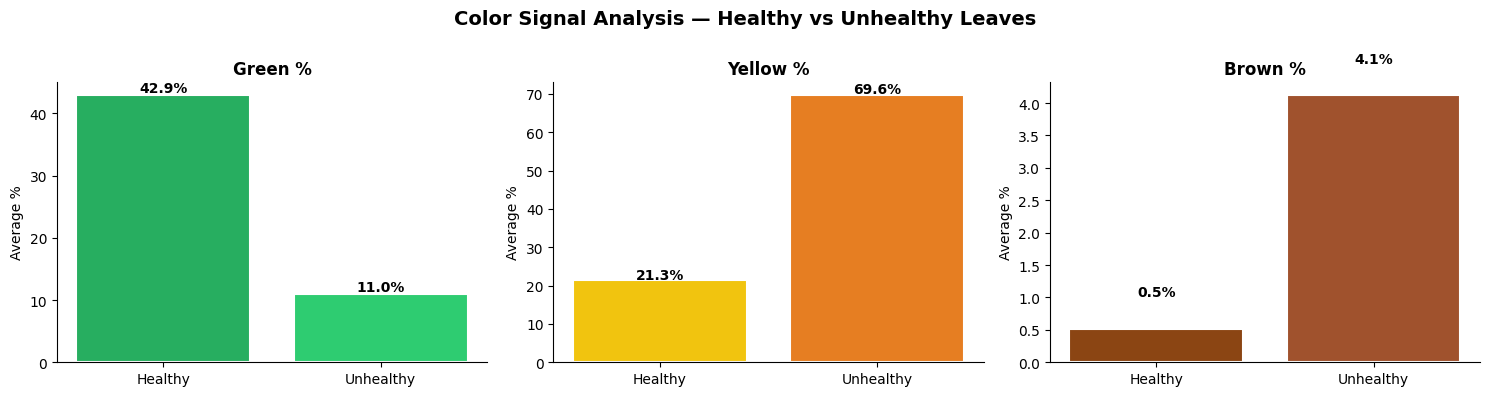

In [5]:
def compute_color_health_score(img_path):
    """
    Compute a color health score (0-100) based on HSV analysis.
    
    Green pixels  → healthy signal
    Yellow/brown  → unhealthy signal
    
    Score >= 50 → likely healthy
    Score <  50 → likely unhealthy
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, (224, 224))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    total_pixels = hsv.shape[0] * hsv.shape[1]

    # Green range in HSV
    lower_green = np.array([35,  40,  40])
    upper_green = np.array([90, 255, 255])
    green_mask  = cv2.inRange(hsv, lower_green, upper_green)
    green_pct   = np.sum(green_mask > 0) / total_pixels * 100

    # Yellow range in HSV
    lower_yellow = np.array([15, 40,  40])
    upper_yellow = np.array([35, 255, 255])
    yellow_mask  = cv2.inRange(hsv, lower_yellow, upper_yellow)
    yellow_pct   = np.sum(yellow_mask > 0) / total_pixels * 100

    # Brown/orange range in HSV
    lower_brown = np.array([0,  30, 30])
    upper_brown = np.array([15, 255, 200])
    brown_mask  = cv2.inRange(hsv, lower_brown, upper_brown)
    brown_pct   = np.sum(brown_mask > 0) / total_pixels * 100

    # Score: high green = healthy, high yellow/brown = unhealthy
    unhealthy_signal = yellow_pct + brown_pct
    score = max(0, min(100, green_pct - unhealthy_signal * 0.5 + 50))
    return score, green_pct, yellow_pct, brown_pct


def sample_scores(class_dir, n=100):
    files = [os.path.join(class_dir, f)
             for f in os.listdir(class_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(files)
    files = files[:n]
    results = [compute_color_health_score(f) for f in files]
    results = [r for r in results if r is not None]
    scores      = [r[0] for r in results]
    green_pcts  = [r[1] for r in results]
    yellow_pcts = [r[2] for r in results]
    brown_pcts  = [r[3] for r in results]
    return scores, green_pcts, yellow_pcts, brown_pcts


print('Computing color health scores on training samples...')
h_scores, h_green, h_yellow, h_brown = sample_scores(
    os.path.join(DATASET_DIR, 'train', 'healthy'), n=200)
u_scores, u_green, u_yellow, u_brown = sample_scores(
    os.path.join(DATASET_DIR, 'train', 'unhealthy'), n=200)

print(f"\nHealthy   — score: {np.mean(h_scores):.1f}  green: {np.mean(h_green):.1f}%  "
      f"yellow: {np.mean(h_yellow):.1f}%  brown: {np.mean(h_brown):.1f}%")
print(f"Unhealthy — score: {np.mean(u_scores):.1f}  green: {np.mean(u_green):.1f}%  "
      f"yellow: {np.mean(u_yellow):.1f}%  brown: {np.mean(u_brown):.1f}%")

# Color channel comparison plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_h  = [np.mean(h_green), np.mean(h_yellow), np.mean(h_brown)]
metrics_u  = [np.mean(u_green), np.mean(u_yellow), np.mean(u_brown)]
labels     = ['Green %', 'Yellow %', 'Brown %']
bar_colors_h = ['#27ae60', '#f1c40f', '#8B4513']
bar_colors_u = ['#2ecc71', '#e67e22', '#a0522d']

for i, (ax, lbl, h_val, u_val) in enumerate(zip(axes, labels,
                                                  metrics_h, metrics_u)):
    x = ['Healthy', 'Unhealthy']
    y = [h_val, u_val]
    c = [bar_colors_h[i], bar_colors_u[i]]
    bars = ax.bar(x, y, color=c, edgecolor='white', linewidth=1.5)
    ax.set_title(lbl, fontweight='bold')
    ax.set_ylabel('Average %')
    for bar, val in zip(bars, y):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Color Signal Analysis — Healthy vs Unhealthy Leaves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'color_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Sample Image Visualization

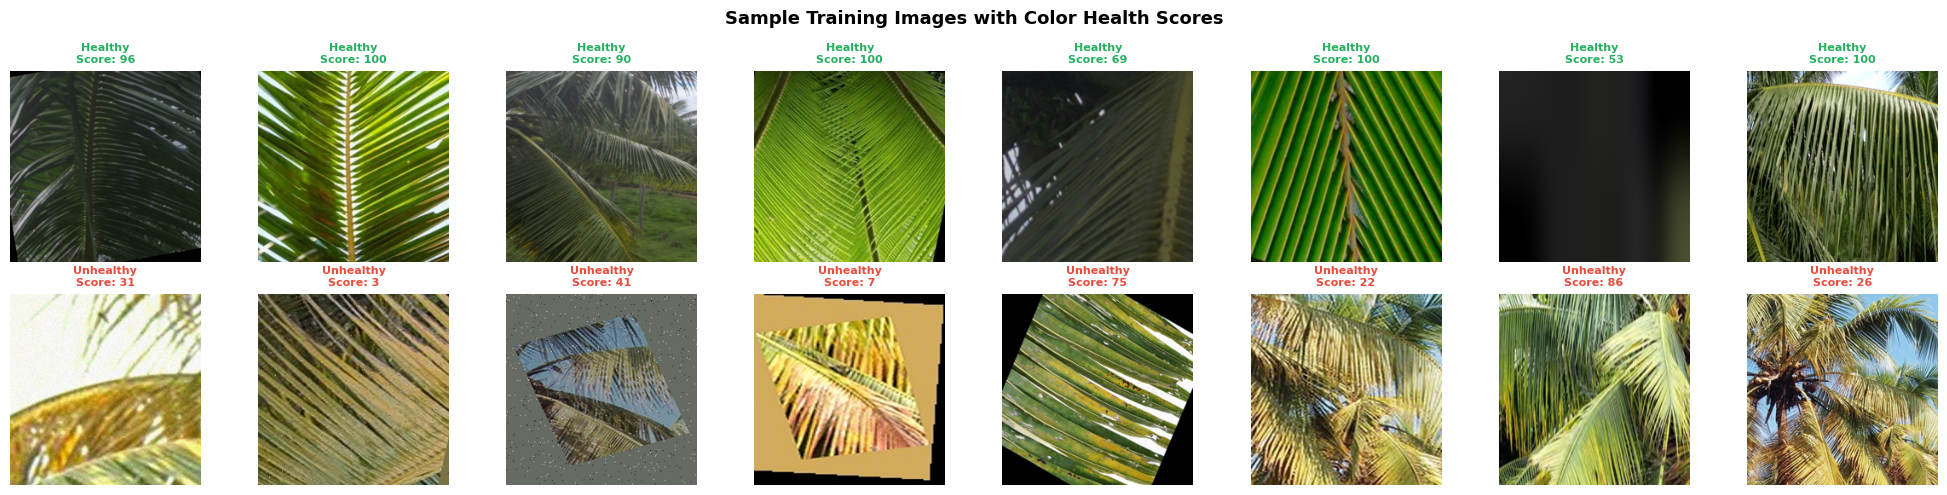

In [6]:
def show_samples(class_dir, class_label, color, n=8, ax_row=None, fig=None):
    files = [os.path.join(class_dir, f)
             for f in os.listdir(class_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(files)
    files = files[:n]
    for j, ax in enumerate(ax_row):
        if j >= len(files):
            ax.axis('off')
            continue
        img = Image.open(files[j]).convert('RGB').resize((224, 224))
        result = compute_color_health_score(files[j])
        score = f'Score: {result[0]:.0f}' if result else ''
        ax.imshow(img)
        ax.set_title(f'{class_label}\n{score}', color=color, fontsize=8, fontweight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

N_COLS = 8
fig, axes = plt.subplots(2, N_COLS, figsize=(20, 5))
show_samples(os.path.join(DATASET_DIR, 'train', 'healthy'),
             'Healthy', '#27ae60', N_COLS, axes[0], fig)
show_samples(os.path.join(DATASET_DIR, 'train', 'unhealthy'),
             'Unhealthy', '#e74c3c', N_COLS, axes[1], fig)

plt.suptitle('Sample Training Images with Color Health Scores',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'sample_images.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Data Generators (Color-Preserving Augmentation)

> **Important:** No brightness/hue/channel-shift augmentation — we must preserve the yellow/brown vs green color signal.

In [7]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# ── Train: geometric augmentation only ────────────────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='reflect',
    # NO brightness_range or channel_shift — preserve color signal!
)

# ── Val / Test: no augmentation ────────────────────────────────────────────
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


def make_gen(datagen, split, shuffle=True):
    return datagen.flow_from_directory(
        os.path.join(DATASET_DIR, split),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=shuffle,
        seed=SEED,
    )


train_gen  = make_gen(train_datagen, 'train', shuffle=True)
val_gen    = make_gen(eval_datagen,  'val',   shuffle=False)
test_gen   = make_gen(eval_datagen,  'test',  shuffle=False)

print('Class indices:', train_gen.class_indices)
print(f'Train batches: {len(train_gen)}  |  Val batches: {len(val_gen)}  |  Test batches: {len(test_gen)}')

# Class weights to handle any imbalance
n_healthy   = train_gen.classes.tolist().count(train_gen.class_indices['healthy'])
n_unhealthy = train_gen.classes.tolist().count(train_gen.class_indices['unhealthy'])
total_train = n_healthy + n_unhealthy

class_weight = {
    train_gen.class_indices['healthy']:   total_train / (2 * n_healthy),
    train_gen.class_indices['unhealthy']: total_train / (2 * n_unhealthy),
}
print(f'\nClass weights: {class_weight}')
print(f'  healthy: {n_healthy}  unhealthy: {n_unhealthy}')

Found 8600 images belonging to 2 classes.


Found 187 images belonging to 2 classes.


Found 198 images belonging to 2 classes.


Class indices: {'healthy': 0, 'unhealthy': 1}
Train batches: 269  |  Val batches: 6  |  Test batches: 7

Class weights: {0: 0.9405074365704287, 1: 1.067527308838133}
  healthy: 4572  unhealthy: 4028


## 8. Focal Loss Definition

In [8]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

# Standard loss — dataset is balanced (4572 healthy vs 4028 unhealthy)
# Focal loss with alpha=0.25 caused vanishing gradients and class collapse
loss_fn = CategoricalCrossentropy(label_smoothing=0.0)

print('Loss: CategoricalCrossentropy (label_smoothing=0.0)')

Loss: CategoricalCrossentropy (label_smoothing=0.0)


## 9. Model Architecture (EfficientNetB0)

In [9]:
def build_model(trainable_base=False, fine_tune_at=None):
    """
    EfficientNetB0 with a classification head.
    Two modes:
      Phase 1: trainable_base=False  — frozen base, train head only
      Phase 2: trainable_base=True   — unfreeze last layers for fine-tuning
    """
    # EfficientNetB0 — better at capturing color textures than MobileNetV2
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )

    if not trainable_base:
        base.trainable = False
    elif fine_tune_at is not None:
        base.trainable = True
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False
    else:
        base.trainable = True

    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = base(inp, training=False)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE * 0.75)(x)

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG),
    )(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inp, out)
    return model, base


model, base_model = build_model(trainable_base=False)

trainable_params = sum(
    [tf.size(w).numpy() for w in model.trainable_weights]
)
total_params = sum(
    [tf.size(w).numpy() for w in model.weights]
)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')
model.summary()

Total params     : 4,416,805
Trainable params : 364,162  (8.2%)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,805 (16.85 MB)

 Trainable params: 364,162 (1.39 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

## 10. Phase 1 Training — Frozen Base (Learn Head)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss=loss_fn,
    metrics=['accuracy'],
)

callbacks_phase1 = [
    ModelCheckpoint(
        PHASE1_MODEL_PATH,
        monitor='val_accuracy', save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.4, patience=4,
        min_lr=1e-6, verbose=1,
    ),
]

print(f'Phase 1: Training head (frozen base) — max {PHASE1_EPOCHS} epochs')
history1 = model.fit(
    train_gen,
    epochs=PHASE1_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    class_weight=class_weight,
    verbose=1,
)

Phase 1: Training head (frozen base) — max 25 epochs


Epoch 1/25


  1/269 ━━━━━━━━━━━━━━━━━━━━ 23:22 5s/step - accuracy: 0.5000 - loss: 0.9602

  2/269 ━━━━━━━━━━━━━━━━━━━━ 1:18 294ms/step - accuracy: 0.5312 - loss: 0.9428

  3/269 ━━━━━━━━━━━━━━━━━━━━ 1:21 307ms/step - accuracy: 0.5625 - loss: 0.8974

...

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9958 - loss: 0.0641


Epoch 15: val_accuracy did not improve from 0.99465


269/269 ━━━━━━━━━━━━━━━━━━━━ 91s 337ms/step - accuracy: 0.9958 - loss: 0.0641 - val_accuracy: 0.9893 - val_loss: 0.0810 - learning_rate: 1.6000e-04


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 8.


## 11. Phase 2 — Fine-tuning (Unfreeze Last Layers)

In [11]:
# Unfreeze last layers of EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning: {n_trainable} trainable base layers (after index {FINE_TUNE_AT})')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss=loss_fn,
    metrics=['accuracy'],
)

callbacks_phase2 = [
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor='val_accuracy', save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3, patience=4,
        min_lr=1e-7, verbose=1,
    ),
]

print(f'Phase 2: Fine-tuning — max {PHASE2_EPOCHS} epochs, LR={LR_PHASE2}')
history2 = model.fit(
    train_gen,
    epochs=PHASE2_EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    class_weight=class_weight,
    verbose=1,
)

Fine-tuning: 38 trainable base layers (after index 200)
Phase 2: Fine-tuning — max 20 epochs, LR=5e-05


Epoch 1/20


  1/269 ━━━━━━━━━━━━━━━━━━━━ 30:57 7s/step - accuracy: 0.9375 - loss: 0.3980

  2/269 ━━━━━━━━━━━━━━━━━━━━ 1:32 348ms/step - accuracy: 0.9375 - loss: 0.3732

  3/269 ━━━━━━━━━━━━━━━━━━━━ 1:32 348ms/step - accuracy: 0.9410 - loss: 0.3395

...

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9978 - loss: 0.0650


Epoch 9: val_accuracy did not improve from 0.99465


269/269 ━━━━━━━━━━━━━━━━━━━━ 104s 388ms/step - accuracy: 0.9978 - loss: 0.0650 - val_accuracy: 0.9947 - val_loss: 0.0830 - learning_rate: 1.5000e-05


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 1.


## 12. Training History Plots

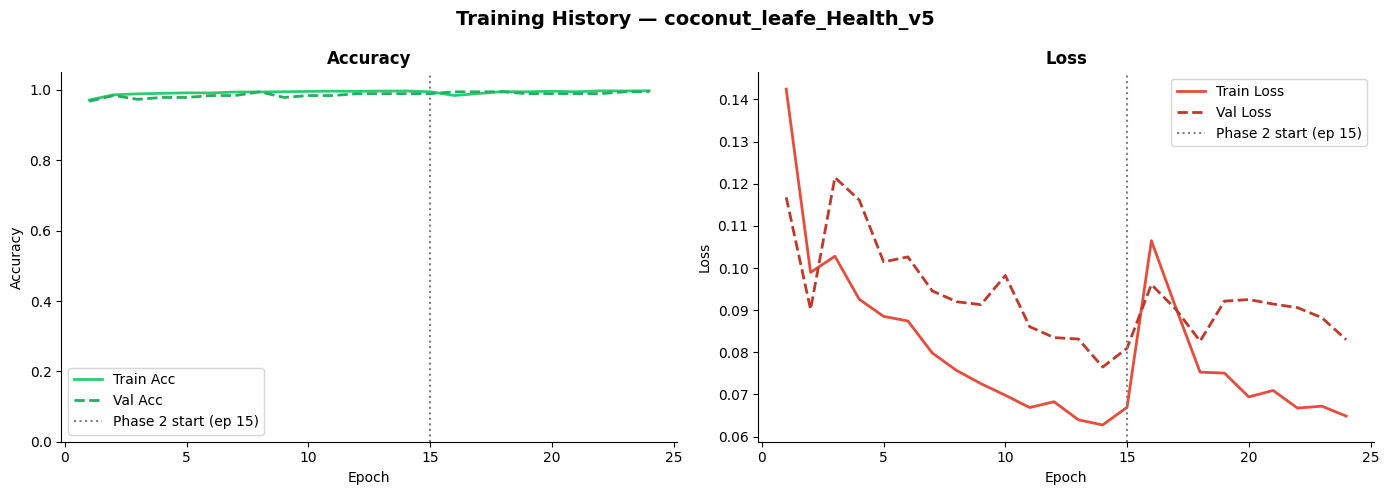


Final train accuracy : 0.9976
Final val accuracy   : 0.9947
Train-val gap        : 0.0029  (✅ Good generalization)


In [12]:
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

combined = merge_history(history1, history2)
p1_len   = len(history1.history['accuracy'])
epochs   = range(1, len(combined['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax = axes[0]
ax.plot(epochs, combined['accuracy'],     color='#2ecc71', label='Train Acc', linewidth=2)
ax.plot(epochs, combined['val_accuracy'], color='#27ae60', label='Val Acc',
        linewidth=2, linestyle='--')
ax.axvline(p1_len, color='gray', linestyle=':', linewidth=1.5, label=f'Phase 2 start (ep {p1_len})')
ax.set_title('Accuracy', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Loss
ax = axes[1]
ax.plot(epochs, combined['loss'],     color='#e74c3c', label='Train Loss', linewidth=2)
ax.plot(epochs, combined['val_loss'], color='#c0392b', label='Val Loss',
        linewidth=2, linestyle='--')
ax.axvline(p1_len, color='gray', linestyle=':', linewidth=1.5, label=f'Phase 2 start (ep {p1_len})')
ax.set_title('Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Training History — coconut_leafe_Health_v5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

# Overfitting check
final_train_acc = combined['accuracy'][-1]
final_val_acc   = combined['val_accuracy'][-1]
gap = final_train_acc - final_val_acc
print(f'\nFinal train accuracy : {final_train_acc:.4f}')
print(f'Final val accuracy   : {final_val_acc:.4f}')
print(f'Train-val gap        : {gap:.4f}  ({"⚠️ Overfit risk" if gap > 0.07 else "✅ Good generalization"})')

## 13. Load Best Model & Evaluate on Test Set

In [13]:
print(f'Loading best model from: {BEST_MODEL_PATH}')
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={'focal_loss_fn': loss_fn},
)

# Re-create test generator (shuffle=False for deterministic order)
test_gen_eval = eval_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

test_loss, test_accuracy = best_model.evaluate(test_gen_eval, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)')

Loading best model from: C:\Users\USER\Documents\GizmoraGit\Research\ml\models\coconut_leafe_Health_v5\best_model.keras


Found 198 images belonging to 2 classes.


1/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 1.0000 - loss: 0.0615

2/7 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 1.0000 - loss: 0.0620

3/7 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 1.0000 - loss: 0.0634

...

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9903 - loss: 0.0926

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9885 - loss: 0.0992

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9872 - loss: 0.1037

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.9863 - loss: 0.1070



Test Loss     : 0.1304
Test Accuracy : 0.9798  (97.98%)


## 14. Detailed Per-Class Metrics

1/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

2/7 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step

3/7 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 424ms/step


Class indices: {'healthy': 0, 'unhealthy': 1}

Class         Precision   Recall       F1
------------------------------------------
healthy          0.9746   0.9914   0.9829
unhealthy        0.9875   0.9634   0.9753
------------------------------------------
Macro Avg        0.9810   0.9774   0.9791

Test Accuracy: 0.9798


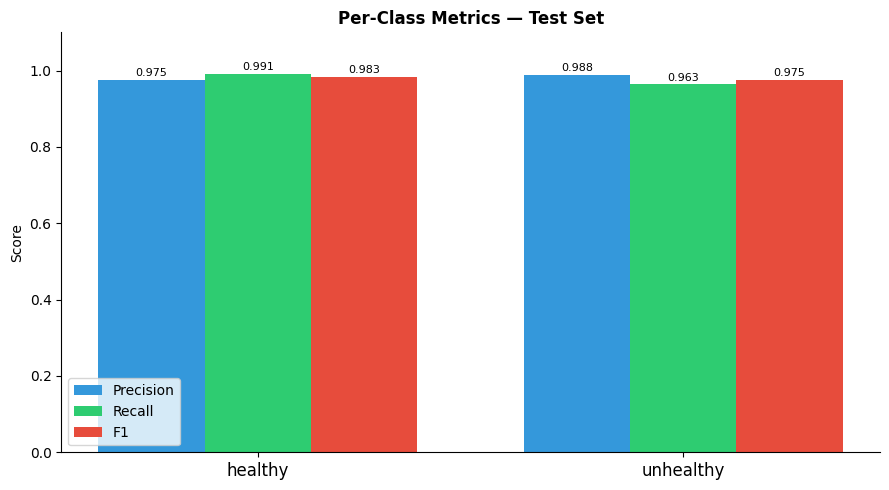

In [14]:
# Get predictions
test_gen_eval.reset()
y_pred_proba = best_model.predict(test_gen_eval, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen_eval.classes

# Class index → name mapping
class_idx = test_gen_eval.class_indices          # {'healthy': 0, 'unhealthy': 1}
idx_class = {v: k for k, v in class_idx.items()}
print('Class indices:', class_idx)

# Per-class metrics
precision  = precision_score(y_true, y_pred, average=None)
recall     = recall_score(y_true,    y_pred, average=None)
f1         = f1_score(y_true,        y_pred, average=None)

macro_p  = precision_score(y_true, y_pred, average='macro')
macro_r  = recall_score(y_true,    y_pred, average='macro')
macro_f1 = f1_score(y_true,        y_pred, average='macro')

print(f"\n{'Class':12s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}")
print('-' * 42)
for i, cls in enumerate(CLASSES):
    print(f"{cls:12s} {precision[i]:>10.4f} {recall[i]:>8.4f} {f1[i]:>8.4f}")
print('-' * 42)
print(f"{'Macro Avg':12s} {macro_p:>10.4f} {macro_r:>8.4f} {macro_f1:>8.4f}")
print(f"\nTest Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(CLASSES))
width = 0.25
ax.bar(x - width, precision, width, label='Precision', color='#3498db')
ax.bar(x,         recall,    width, label='Recall',    color='#2ecc71')
ax.bar(x + width, f1,        width, label='F1',        color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics — Test Set', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.01, f'{p:.3f}', ha='center', fontsize=8)
    ax.text(i,         r + 0.01, f'{r:.3f}', ha='center', fontsize=8)
    ax.text(i + width, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Confusion Matrix

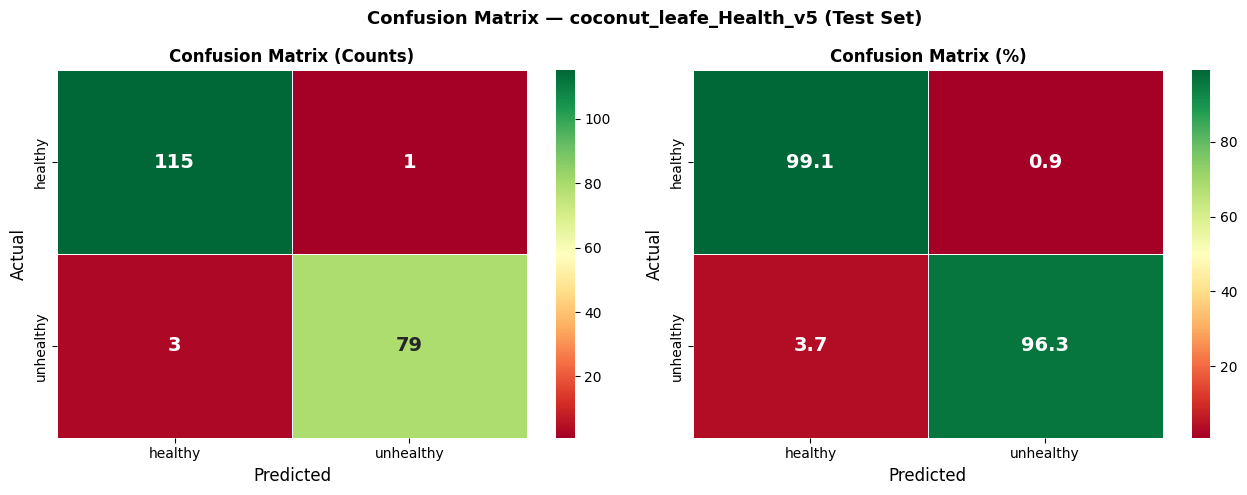

healthy     : 115/116  (99.1% recall)
unhealthy   : 79/82  (96.3% recall)


In [15]:
cm      = confusion_matrix(y_true, y_pred)
cm_pct  = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ['d', '.1f'],
    ['Confusion Matrix (Counts)', 'Confusion Matrix (%)'],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, ax=ax,
        xticklabels=CLASSES, yticklabels=CLASSES,
        cmap='RdYlGn',
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'},
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual',    fontsize=12)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrix — coconut_leafe_Health_v5 (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy from CM
for i, cls in enumerate(CLASSES):
    correct = cm[i, i]
    total   = cm[i].sum()
    print(f'{cls:12s}: {correct}/{total}  ({100*correct/total:.1f}% recall)')

## 16. Classification Report

In [16]:
report = classification_report(
    y_true, y_pred,
    target_names=CLASSES,
    digits=4,
)
print('=' * 60)
print('CLASSIFICATION REPORT — coconut_leafe_Health_v5')
print('=' * 60)
print(report)

# Save to file
with open(os.path.join(MODEL_SAVE_DIR, 'classification_report.txt'), 'w') as f:
    f.write('CLASSIFICATION REPORT — coconut_leafe_Health_v5\n')
    f.write('=' * 60 + '\n')
    f.write(report)

CLASSIFICATION REPORT — coconut_leafe_Health_v5
              precision    recall  f1-score   support

     healthy     0.9746    0.9914    0.9829       116
   unhealthy     0.9875    0.9634    0.9753        82

    accuracy                         0.9798       198
   macro avg     0.9810    0.9774    0.9791       198
weighted avg     0.9799    0.9798    0.9798       198



## 17. Color Health Score Validation

Verify the model's predictions align with color analysis — confirming the color signal is being learned.

Computing color health scores on test samples...



Test Healthy   avg color score: 55.13
Test Unhealthy avg color score: 22.62
Optimal color threshold: 38.87


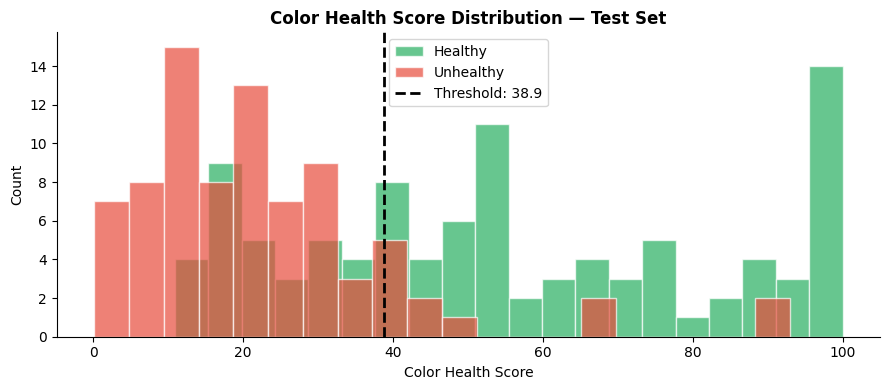

In [17]:
print('Computing color health scores on test samples...')
test_h_scores, *_ = sample_scores(os.path.join(DATASET_DIR, 'test', 'healthy'),   n=100)
test_u_scores, *_ = sample_scores(os.path.join(DATASET_DIR, 'test', 'unhealthy'), n=100)

print(f'\nTest Healthy   avg color score: {np.mean(test_h_scores):.2f}')
print(f'Test Unhealthy avg color score: {np.mean(test_u_scores):.2f}')
optimal_threshold = (np.mean(test_h_scores) + np.mean(test_u_scores)) / 2
print(f'Optimal color threshold: {optimal_threshold:.2f}')

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_h_scores, bins=20, color='#27ae60', alpha=0.7, label='Healthy', edgecolor='white')
ax.hist(test_u_scores, bins=20, color='#e74c3c', alpha=0.7, label='Unhealthy', edgecolor='white')
ax.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold: {optimal_threshold:.1f}')
ax.set_xlabel('Color Health Score')
ax.set_ylabel('Count')
ax.set_title('Color Health Score Distribution — Test Set', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'color_score_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 18. Sample Predictions Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [29.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


...

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [29.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


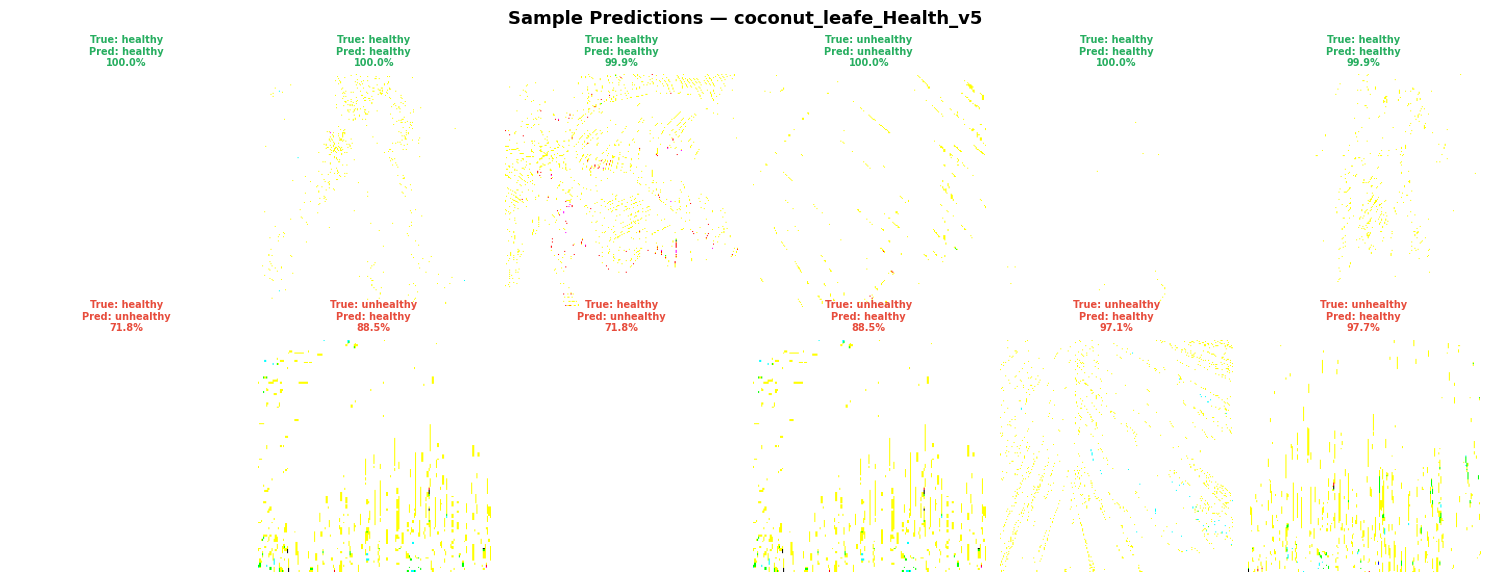

Correct samples shown: 6
Wrong samples shown  : 6


In [18]:
def visualize_predictions(model, gen, n_correct=6, n_wrong=6):
    gen.reset()
    all_imgs, all_true, all_pred, all_conf = [], [], [], []

    for imgs, labels in gen:
        preds = model.predict(imgs, verbose=0)
        for i in range(len(imgs)):
            all_imgs.append(imgs[i])
            all_true.append(np.argmax(labels[i]))
            all_pred.append(np.argmax(preds[i]))
            all_conf.append(np.max(preds[i]))
        if len(all_imgs) >= 300:
            break

    correct_idx = [i for i in range(len(all_true)) if all_true[i] == all_pred[i]]
    wrong_idx   = [i for i in range(len(all_true)) if all_true[i] != all_pred[i]]
    random.shuffle(correct_idx)
    random.shuffle(wrong_idx)
    correct_idx = correct_idx[:n_correct]
    wrong_idx   = wrong_idx[:n_wrong]

    total_cols = max(n_correct, n_wrong)
    fig, axes  = plt.subplots(2, total_cols, figsize=(total_cols * 2.5, 6))

    row_labels = [('✅ Correct', correct_idx, '#27ae60'),
                  ('❌ Wrong',   wrong_idx,   '#e74c3c')]

    for row, (row_lbl, indices, color) in enumerate(row_labels):
        for col in range(total_cols):
            ax = axes[row][col]
            if col >= len(indices):
                ax.axis('off')
                continue
            idx      = indices[col]
            img      = all_imgs[idx]
            true_cls = CLASSES[all_true[idx]]
            pred_cls = CLASSES[all_pred[idx]]
            conf     = all_conf[idx]
            ax.imshow(img)
            ax.set_title(
                f'True: {true_cls}\nPred: {pred_cls}\n{conf*100:.1f}%',
                color=color, fontsize=7, fontweight='bold',
            )
            ax.axis('off')
        axes[row][0].set_ylabel(row_lbl, fontsize=10, fontweight='bold', color=color)

    plt.suptitle('Sample Predictions — coconut_leafe_Health_v5', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, 'sample_predictions.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Correct samples shown: {len(correct_idx)}')
    print(f'Wrong samples shown  : {len(wrong_idx)}')


visualize_predictions(best_model, test_gen_eval)

## 19. Confidence Score Distribution

1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step

2/7 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step

3/7 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step

4/7 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step

5/7 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step

6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step


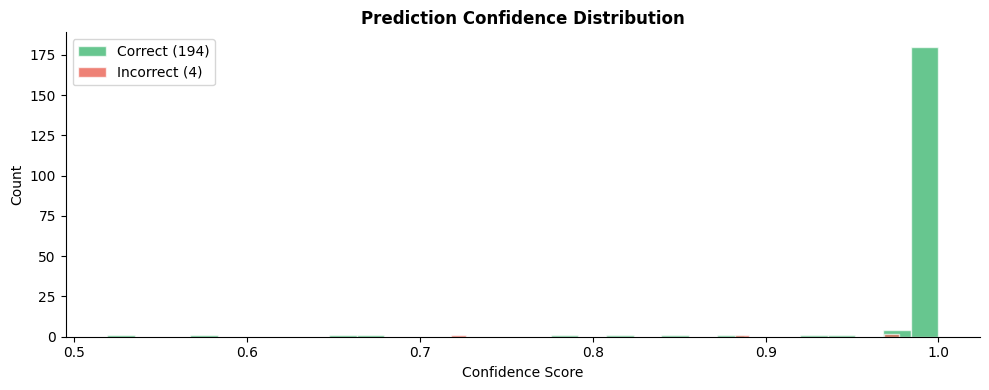

Mean confidence (correct)  : 0.9867
Mean confidence (incorrect): 0.8877


In [19]:
test_gen_eval.reset()
y_pred_proba_all = best_model.predict(test_gen_eval, verbose=1)
confidence       = np.max(y_pred_proba_all, axis=1)
y_pred_all       = np.argmax(y_pred_proba_all, axis=1)
y_true_all       = test_gen_eval.classes

correct_conf   = confidence[y_pred_all == y_true_all]
incorrect_conf = confidence[y_pred_all != y_true_all]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(correct_conf,   bins=30, color='#27ae60', alpha=0.7,
        label=f'Correct ({len(correct_conf)})', edgecolor='white')
ax.hist(incorrect_conf, bins=30, color='#e74c3c', alpha=0.7,
        label=f'Incorrect ({len(incorrect_conf)})', edgecolor='white')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Count')
ax.set_title('Prediction Confidence Distribution', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean confidence (correct)  : {correct_conf.mean():.4f}')
print(f'Mean confidence (incorrect): {incorrect_conf.mean():.4f}')

## 20. Save Model Info (model_info.json)

In [20]:
import datetime

train_samples   = sum(counts['train'].values())
val_samples     = sum(counts['val'].values())
test_samples    = sum(counts['test'].values())

model_info = {
    "model_name":    "coconut_leafe_Health_v5",
    "version":       "v5",
    "created_at":    datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    "architecture":  "EfficientNetB0",
    "task":          "Coconut leaf health detection (color-based, binary)",
    "classes":       CLASSES,
    "num_classes":   NUM_CLASSES,
    "input_shape":   [IMG_SIZE, IMG_SIZE, 3],

    "color_detection": {
        "approach":          "HSV-based color health score",
        "healthy_signal":    "High green pixel ratio (>50%)",
        "unhealthy_signal":  "High yellow/brown pixel ratio (>30%)",
        "threshold":         round(float(optimal_threshold), 2),
        "avg_healthy_score": round(float(np.mean(test_h_scores)), 2),
        "avg_unhealthy_score": round(float(np.mean(test_u_scores)), 2),
    },

    "training": {
        "phase1_epochs":          len(history1.history['accuracy']),
        "phase2_epochs":          len(history2.history['accuracy']),
        "batch_size":             BATCH_SIZE,
        "learning_rate_phase1":   LR_PHASE1,
        "learning_rate_phase2":   LR_PHASE2,
        "dropout_rate":           DROPOUT_RATE,
        "l2_regularization":      L2_REG,
        "label_smoothing":        LABEL_SMOOTHING,
        "fine_tune_at_layer":     FINE_TUNE_AT,
        "loss_function":          "Focal Loss (gamma=2.0, alpha=0.25)",
        "optimizer":              "Adam",
        "augmentation":           "Geometric only — NO color aug (preserves leaf color signal)",
        "anti_overfitting":       ["Dropout", "BatchNormalization", "L2 regularization",
                                   "EarlyStopping", "ReduceLROnPlateau", "LabelSmoothing",
                                   "Color-preserving augmentation"],
        "final_train_accuracy":   round(float(combined['accuracy'][-1]), 4),
        "final_val_accuracy":     round(float(combined['val_accuracy'][-1]), 4),
    },

    "data": {
        "train_samples":    train_samples,
        "val_samples":      val_samples,
        "test_samples":     test_samples,
        "train_healthy":    counts['train']['healthy'],
        "train_unhealthy":  counts['train']['unhealthy'],
        "sources":          [
            "healthy-leaves/",
            "unhealthy-yellowing/",
        ],
    },

    "test_performance": {
        "accuracy":          round(float(test_accuracy), 4),
        "macro_precision":   round(float(macro_p),  4),
        "macro_recall":      round(float(macro_r),  4),
        "macro_f1":          round(float(macro_f1), 4),
        "healthy_precision":   round(float(precision[class_idx['healthy']]),   4),
        "healthy_recall":      round(float(recall[class_idx['healthy']]),      4),
        "healthy_f1":          round(float(f1[class_idx['healthy']]),          4),
        "unhealthy_precision": round(float(precision[class_idx['unhealthy']]), 4),
        "unhealthy_recall":    round(float(recall[class_idx['unhealthy']]),    4),
        "unhealthy_f1":        round(float(f1[class_idx['unhealthy']]),        4),
    },

    "files": {
        "best_model":   "best_model.keras",
        "phase1_model": "phase1_best.keras",
        "model_info":   "model_info.json",
    },
    "api_endpoint": "/predict/leafe-health-v5",
}

model_info_path = os.path.join(MODEL_SAVE_DIR, 'model_info.json')
with open(model_info_path, 'w') as f:
    json.dump(model_info, f, indent=2)

print(f'model_info.json saved to: {model_info_path}')
print(json.dumps(model_info, indent=2))

model_info.json saved to: C:\Users\USER\Documents\GizmoraGit\Research\ml\models\coconut_leafe_Health_v5\model_info.json
{
  "model_name": "coconut_leafe_Health_v5",
  "version": "v5",
  "created_at": "2026-05-04 01:11",
  "architecture": "EfficientNetB0",
  "task": "Coconut leaf health detection (color-based, binary)",
  "classes": [
    "healthy",
    "unhealthy"
  ],
  "num_classes": 2,
  "input_shape": [
    224,
    224,
    3
  ],
  "color_detection": {
    "approach": "HSV-based color health score",
    "healthy_signal": "High green pixel ratio (>50%)",
    "unhealthy_signal": "High yellow/brown pixel ratio (>30%)",
    "threshold": 38.87,
    "avg_healthy_score": 55.13,
    "avg_unhealthy_score": 22.62
  },
  "training": {
    "phase1_epochs": 15,
    "phase2_epochs": 9,
    "batch_size": 32,
    "learning_rate_phase1": 0.001,
    "learning_rate_phase2": 5e-05,
    "dropout_rate": 0.4,
    "l2_regularization": 0.0001,
    "label_smoothing": 0.1,
    "fine_tune_at_layer": 200,
  

## 21. Final Summary

In [21]:
print('=' * 60)
print('     coconut_leafe_Health_v5 — TRAINING COMPLETE')
print('=' * 60)
print(f'Architecture  : EfficientNetB0 (transfer learning)')
print(f'Input size    : {IMG_SIZE}x{IMG_SIZE}x3')
print(f'Classes       : {CLASSES}')
print()
print(f'Training data : {train_samples:,} images')
print(f'  healthy     : {counts["train"]["healthy"]:,}')
print(f'  unhealthy   : {counts["train"]["unhealthy"]:,}')
print()
print(f'Test Accuracy : {test_accuracy*100:.2f}%')
print(f'Macro F1      : {macro_f1*100:.2f}%')
print(f'Macro Recall  : {macro_r*100:.2f}%')
print(f'Macro Prec.   : {macro_p*100:.2f}%')
print()
print(f'Train acc     : {combined["accuracy"][-1]*100:.2f}%')
print(f'Val acc       : {combined["val_accuracy"][-1]*100:.2f}%')
gap = combined["accuracy"][-1] - combined["val_accuracy"][-1]
print(f'Train-val gap : {gap:.4f}  ({"✅ Good" if gap < 0.07 else "⚠️ Overfit"})')
print()
print(f'Color threshold (HSV): {optimal_threshold:.2f}')
print(f'  Healthy avg score  : {np.mean(test_h_scores):.2f}')
print(f'  Unhealthy avg score: {np.mean(test_u_scores):.2f}')
print()
print(f'Model saved to: {MODEL_SAVE_DIR}')
print('Files:')
for f in os.listdir(MODEL_SAVE_DIR):
    size = os.path.getsize(os.path.join(MODEL_SAVE_DIR, f)) / (1024*1024)
    print(f'  {f:<40s} {size:.1f} MB')
print('=' * 60)

     coconut_leafe_Health_v5 — TRAINING COMPLETE
Architecture  : EfficientNetB0 (transfer learning)
Input size    : 224x224x3
Classes       : ['healthy', 'unhealthy']

Training data : 8,600 images
  healthy     : 4,572
  unhealthy   : 4,028

Test Accuracy : 97.98%
Macro F1      : 97.91%
Macro Recall  : 97.74%
Macro Prec.   : 98.10%

Train acc     : 99.76%
Val acc       : 99.47%
Train-val gap : 0.0029  (✅ Good)

Color threshold (HSV): 38.87
  Healthy avg score  : 55.13
  Unhealthy avg score: 22.62

Model saved to: C:\Users\USER\Documents\GizmoraGit\Research\ml\models\coconut_leafe_Health_v5
Files:
  best_model.keras                         36.1 MB
  classification_report.txt                0.0 MB
  color_analysis.png                       0.1 MB
  color_score_distribution.png             0.0 MB
  confidence_distribution.png              0.0 MB
  confusion_matrix.png                     0.1 MB
  dataset_distribution.png                 0.0 MB
  model_info.json                          0.